# Gerador e receptor de sinais FSK

## Instruções

Criar um código python que simula a geração e recepção de sinais FSK. Incluir no github o código totalmente comentado.

<a href="https://colab.research.google.com/github/jgocana/Trabalhos-TP-547/blob/master/Trabalho%203/fsk_tx_rx.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

BFSK Modem Simulation (Coherent and Non‑Coherent)

Based on:
D. A. Guimarães, "Digital Transmission – A Simulation‑Aided Introduction 
with VisSim/Comm", Chapter 6.

This script simulates:
- BFSK signal generation
- AWGN channel
- Coherent BFSK detection (correlator / ML)
- Non‑coherent BFSK detection (energy detector)
- Bit Error Rate (BER) estimation

In [ ]:
!pip install numpy
!pip install matplotlib

=== RESULTADOS ===
Bits transmitidos        : [1 0 1 1 0 0 1]
Bits recebidos (coerente): [1 0 1 1 0 0 1]
Bits recebidos (não‑coer): [1 0 1 1 0 0 1]
BER Coerente             : 0.00000000
BER Não‑coerente         : 0.00000000


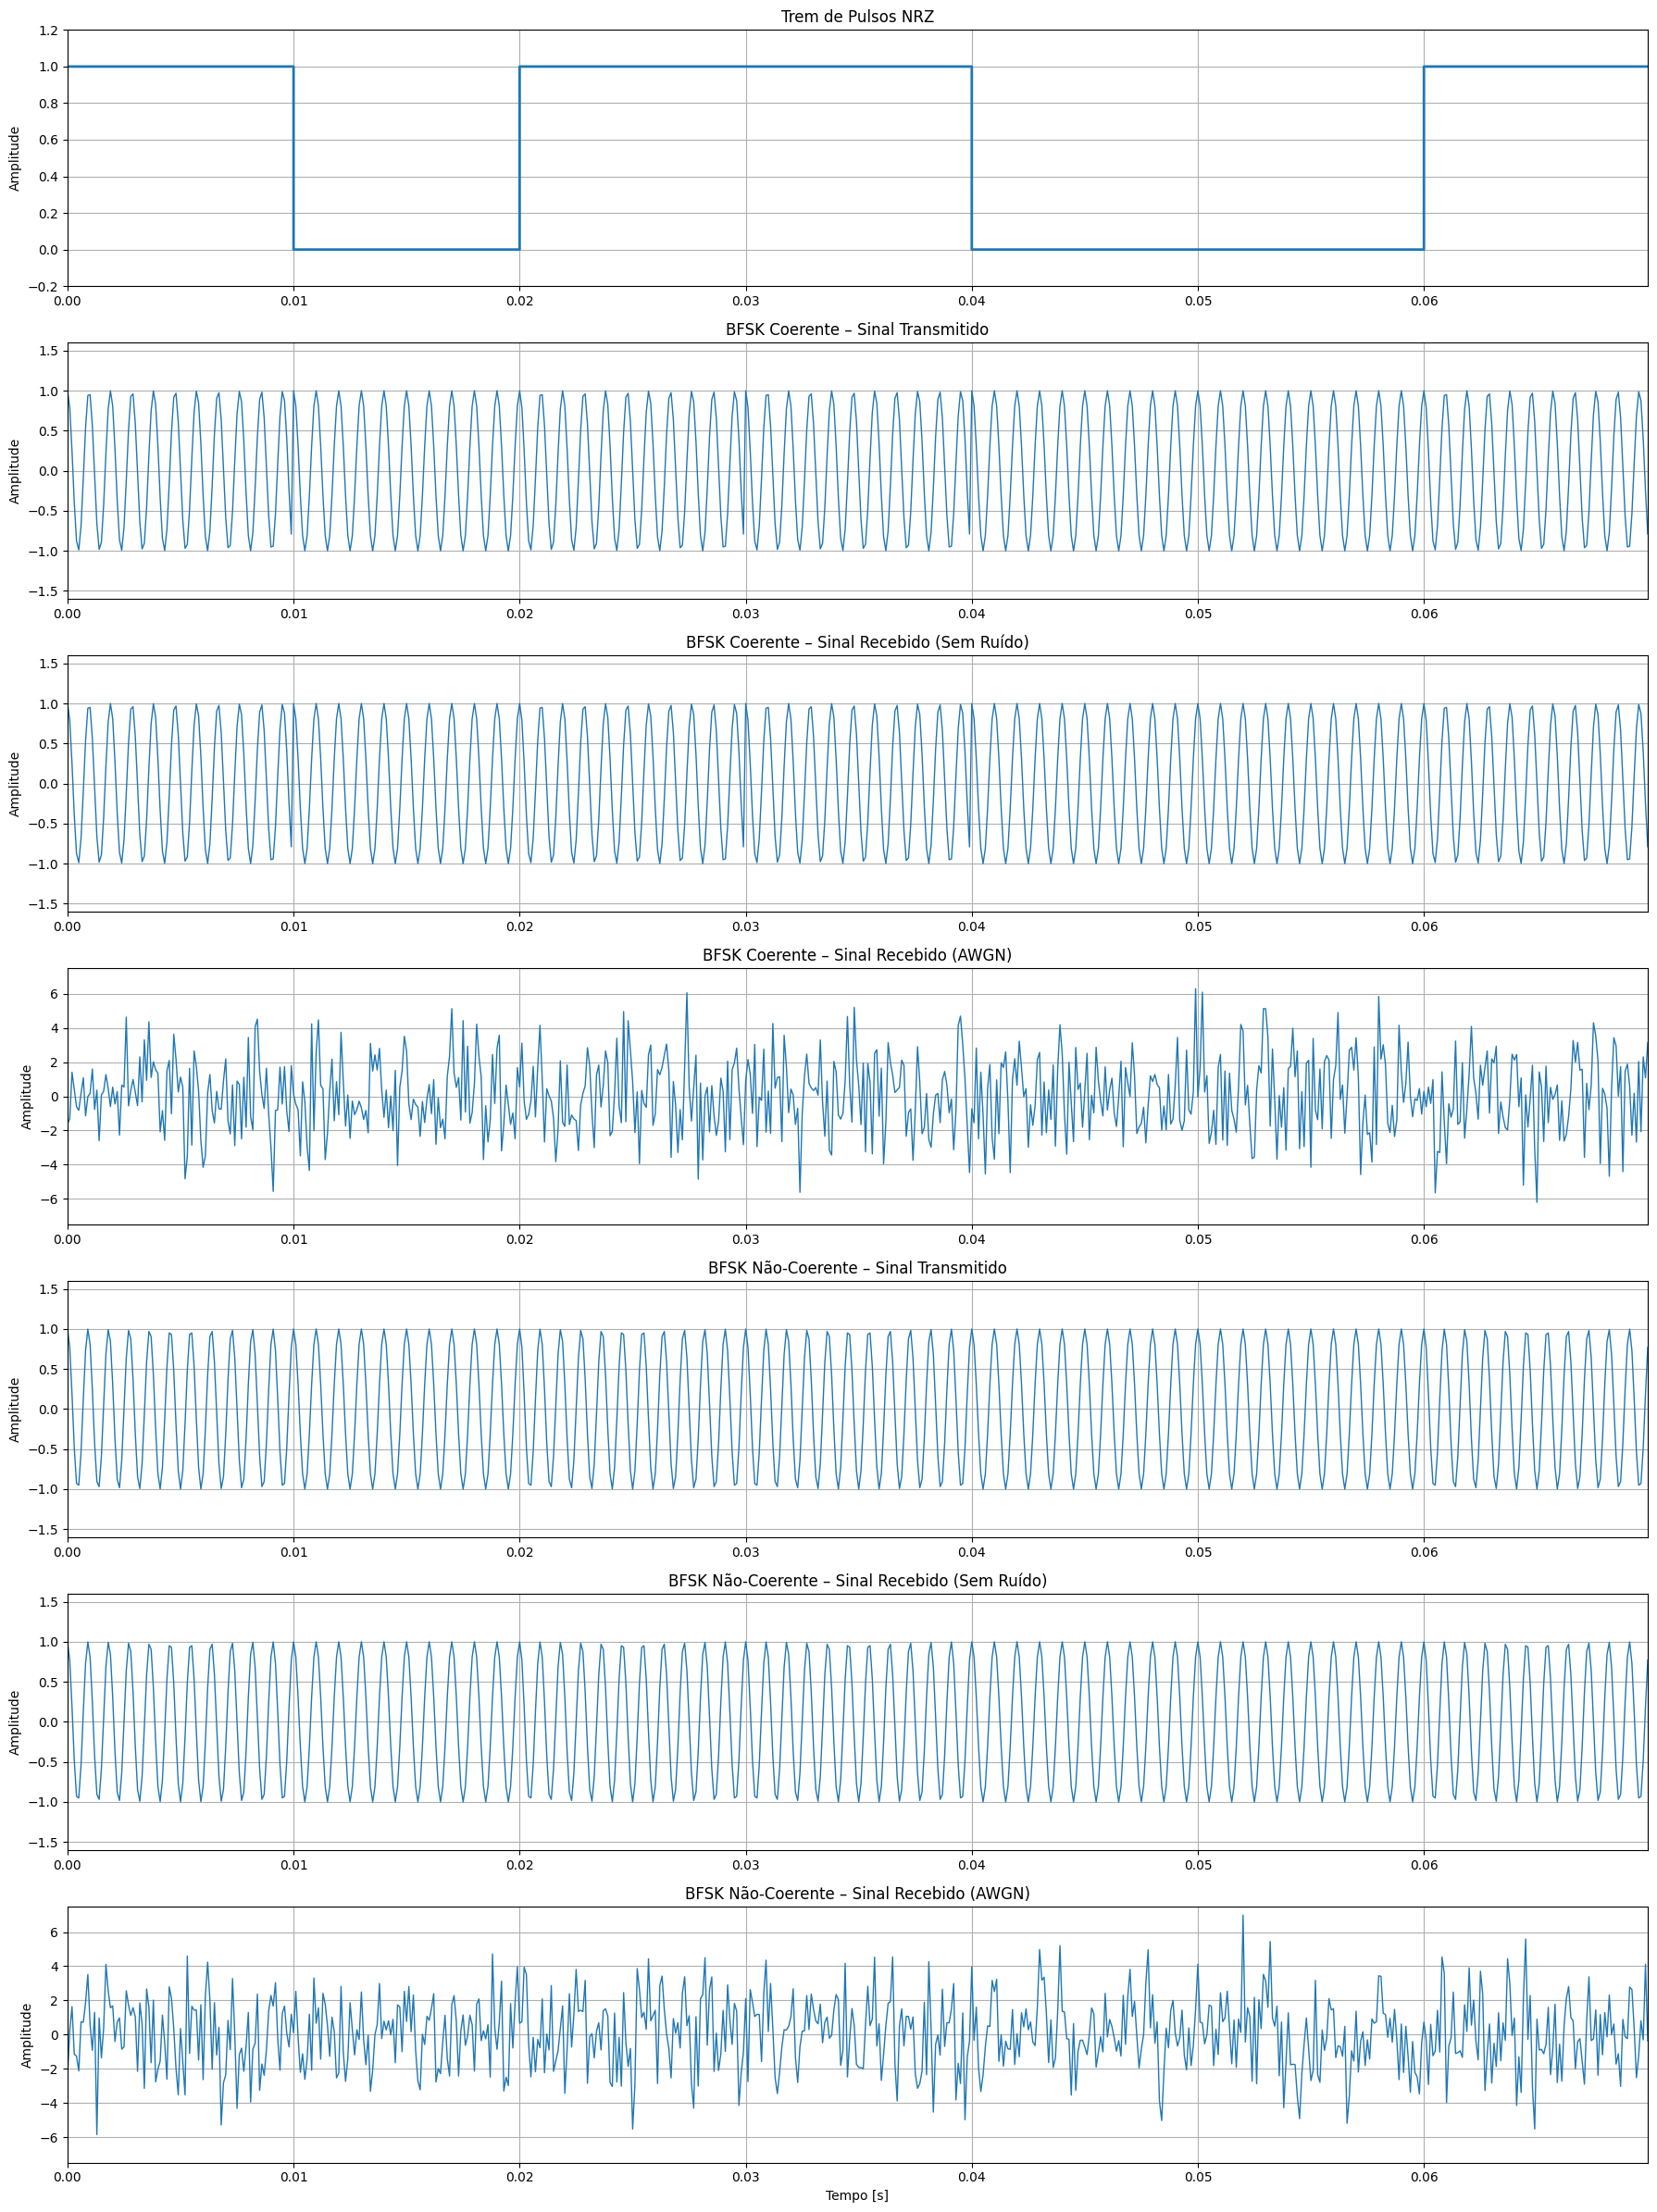

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. PARÂMETROS DO SISTEMA
# ============================================================
# Definição dos parâmetros básicos da transmissão digital

Fs = 10_000              # Frequência de amostragem [Hz]
Tb = 0.01                # Duração de cada bit [s]
A = 1.0                  # Amplitude da portadora
bits_tx = np.array([1, 0, 1, 1, 0, 0, 1])  # Sequência de bits transmitidos

# Número de amostras que representam um bit
samples_per_bit = int(Tb * Fs)

# Energia por bit para uma portadora cossenoidal
# Eb = (A² / 2) * Tb
Eb = (A ** 2) * Tb / 2

# Eixo de tempo total da simulação
t = np.arange(0, len(bits_tx) * samples_per_bit) / Fs


# ============================================================
# 2. FREQUÊNCIAS BFSK (CRITÉRIO DE ORTOGONALIDADE)
# ============================================================
# Conforme a teoria (Guimarães):
# - BFSK coerente: Δf = 1 / (2Tb)
# - BFSK não‑coerente: Δf = 1 / Tb

f0 = 1000                  # Frequência associada ao bit 0 [Hz]

Df_coh = 1 / (2 * Tb)      # Separação de frequência (coerente)
Df_ncoh = 1 / Tb           # Separação de frequência (não‑coerente)

# Frequência associada ao bit 1
f1_coh = f0 + Df_coh
f1_ncoh = f0 + Df_ncoh


# ============================================================
# 3. MODULADOR BFSK
# ============================================================
# Converte a sequência de bits em uma forma de onda BFSK

def fsk_modulator(bits, f0, f1):
    """
    Modulador BFSK:
    - Bit 0 → portadora com frequência f0
    - Bit 1 → portadora com frequência f1
    """
    t_bit = np.arange(0, Tb, 1 / Fs)  # Tempo correspondente a um bit
    signal = []

    for b in bits:
        # Seleciona a frequência de acordo com o bit
        f = f1 if b == 1 else f0

        # Gera a portadora cossenoidal para o intervalo Tb
        signal.extend(A * np.cos(2 * np.pi * f * t_bit))

    return np.array(signal)


# ============================================================
# 4. CANAL AWGN
# ============================================================
# Modelo de canal com Ruído Branco Gaussiano Aditivo (AWGN)

def awgn(signal, snr_db):
    """
    Adiciona ruído AWGN à sinal transmitida.
    snr_db representa Eb/N0 em decibéis.
    """
    snr_linear = 10 ** (snr_db / 10)  # Conversão dB → escala linear
    N0 = Eb / snr_linear              # Densidade espectral de ruído
    noise_var = N0 * Fs / 2           # Variância do ruído
    noise = np.sqrt(noise_var) * np.random.randn(len(signal))

    return signal + noise


# ============================================================
# 5. RECEPTOR BFSK COERENTE
# ============================================================
# Implementa detecção coerente usando correladores
# Requer sincronização de fase com o transmissor

def bfsk_coherent_receiver(rx_signal, f0, f1):
    """
    Receptor BFSK coerente.
    A decisão é baseada na saída dos correladores.
    """
    detected_bits = []
    t_bit = np.arange(0, Tb, 1 / Fs)

    for i in range(len(bits_tx)):
        # Extrai o trecho da sinal correspondente a um bit
        r = rx_signal[i * samples_per_bit:(i + 1) * samples_per_bit]

        # Sinais de referência locais
        phi0 = np.cos(2 * np.pi * f0 * t_bit)
        phi1 = np.cos(2 * np.pi * f1 * t_bit)

        # Saída dos correladores
        z0 = np.sum(r * phi0)
        z1 = np.sum(r * phi1)

        # Regra de decisão (máxima correlação)
        detected_bits.append(1 if z1 > z0 else 0)

    return np.array(detected_bits)


# ============================================================
# 6. RECEPTOR BFSK NÃO‑COERENTE
# ============================================================
# Não exige sincronização de fase
# Baseia‑se na comparação de energia

def bfsk_noncoherent_receiver(rx_signal, f0, f1):
    """
    Receptor BFSK não‑coerente.
    A decisão é feita com base na energia do sinal.
    """
    detected_bits = []
    t_bit = np.arange(0, Tb, 1 / Fs)

    for i in range(len(bits_tx)):
        r = rx_signal[i * samples_per_bit:(i + 1) * samples_per_bit]

        # Componentes I/Q para frequência f0
        i0 = np.sum(r * np.cos(2 * np.pi * f0 * t_bit))
        q0 = np.sum(r * np.sin(2 * np.pi * f0 * t_bit))
        e0 = i0**2 + q0**2

        # Componentes I/Q para frequência f1
        i1 = np.sum(r * np.cos(2 * np.pi * f1 * t_bit))
        q1 = np.sum(r * np.sin(2 * np.pi * f1 * t_bit))
        e1 = i1**2 + q1**2

        # Decisão: maior energia
        detected_bits.append(1 if e1 > e0 else 0)

    return np.array(detected_bits)


# ============================================================
# 7. SIMULAÇÃO
# ============================================================

snr_db = 8  # Eb/N0 em dB

# ----- BFSK COERENTE -----
tx_coh = fsk_modulator(bits_tx, f0, f1_coh)
rx_coh = awgn(tx_coh, snr_db)
bits_rx_coh = bfsk_coherent_receiver(rx_coh, f0, f1_coh)

# ----- BFSK NÃO‑COERENTE -----
tx_ncoh = fsk_modulator(bits_tx, f0, f1_ncoh)
rx_ncoh = awgn(tx_ncoh, snr_db)
bits_rx_ncoh = bfsk_noncoherent_receiver(rx_ncoh, f0, f1_ncoh)


# ============================================================
# 8. CÁLCULO DA TAXA DE ERRO DE BIT (BER)
# ============================================================

ber_coh = np.mean(bits_tx != bits_rx_coh)
ber_ncoh = np.mean(bits_tx != bits_rx_ncoh)

print("=== RESULTADOS ===")
print(f"Bits transmitidos        : {bits_tx}")
print(f"Bits recebidos (coerente): {bits_rx_coh}")
print(f"Bits recebidos (não‑coer): {bits_rx_ncoh}")
print(f"BER Coerente             : {ber_coh:.8f}")
print(f"BER Não‑coerente         : {ber_ncoh:.8f}")


# ============================================================
# 9. VISUALIZAÇÃO DAS SINAIS
# ============================================================

# Trem de pulsos NRZ (apenas ilustrativo)
pulse_train = np.repeat(bits_tx, samples_per_bit)
t_end = t[-1]

plt.figure(figsize=(18, 24))

signals = [
    (pulse_train, t, "Trem de Pulsos NRZ", (-0.2, 1.2), "step"),

    (tx_coh, t, "BFSK Coerente – Sinal Transmitido", (-1.6, 1.6), "plot"),
    (tx_coh, t, "BFSK Coerente – Sinal Recebido (Sem Ruído)", (-1.6, 1.6), "plot"),
    (rx_coh, t, "BFSK Coerente – Sinal Recebido (AWGN)", (-7.5, 7.5), "plot"),

    (tx_ncoh, t, "BFSK Não‑Coerente – Sinal Transmitido", (-1.6, 1.6), "plot"),
    (tx_ncoh, t, "BFSK Não‑Coerente – Sinal Recebido (Sem Ruído)", (-1.6, 1.6), "plot"),
    (rx_ncoh, t, "BFSK Não‑Coerente – Sinal Recebido (AWGN)", (-7.5, 7.5), "plot"),
]

for i, (signal, time, title, ylim, mode) in enumerate(signals, 1):
    plt.subplot(len(signals), 1, i)

    if mode == "step":
        plt.step(time, signal, where="post", linewidth=2)
    else:
        plt.plot(time, signal, linewidth=1)

    plt.title(title)
    plt.ylabel("Amplitude")
    plt.ylim(ylim)
    plt.xlim(0, t_end)
    plt.grid(True)

plt.xlabel("Tempo [s]")
plt.tight_layout()
plt.show()

## Resumo do Sistema BFSK Simulado

Este projeto implementa uma transmissão **BFSK (Binary Frequency Shift Keying)** completa, incluindo modulação, canal com ruído AWGN e demodulação **coerente** e **não‑coerente**, com foco didático e alinhamento com a teoria clássica de comunicações digitais.

### 🔹 Modulação BFSK
Cada bit é representado por uma portadora senoidal distinta:

- **`f0`** para o bit `0`
- **`f1`** para o bit `1`

As frequências são escolhidas de modo a garantir **ortogonalidade no intervalo de bit**, conforme os critérios teóricos de BFSK.

### 🔹 Canal AWGN
O canal é modelado como um **canal aditivo com ruído branco gaussiano (AWGN)**.  
São considerados três cenários:

- Sem ruído  
- Com ruído de baixa potência  
- Com ruído de alta potência  

Esses cenários permitem observar claramente o impacto do ruído no desempenho do receptor.

### 🔹 Demodulação Coerente
A demodulação coerente utiliza **correladores com sinais de referência em fase conhecida**, exigindo sincronização de portadora.  
Esse método apresenta **melhor desempenho em termos de taxa de erro**, conforme previsto pela teoria de BFSK.

### 🔹 Demodulação Não‑Coerente
A demodulação não‑coerente baseia‑se na **comparação de energia** das componentes em fase (I) e em quadratura (Q), dispensando sincronização de fase.  
Embora mais simples de implementar, apresenta **pior desempenho sob níveis elevados de ruído**.

### 🔹 Visualização dos Sinais
Os gráficos apresentados no notebook incluem:

- Trem de pulsos NRZ  
- Sinais BFSK transmitidos  
- Sinais recebidos (com e sem ruído)  
- Sinais reconstruídos após a decisão no receptor  

Essas visualizações têm **caráter ilustrativo**, auxiliando na compreensão do funcionamento do sistema.

### Conclusão
Os resultados obtidos confirmam que a **detecção coerente é mais robusta ao ruído** do que a detecção não‑coerente, em plena concordância com a teoria de BFSK apresentada na literatura de comunicações digitais.